In [1]:
%load_ext autoreload
%autoreload 2

# Model Training: *RelBench* Regression Task

`Task Description: Predict the average finishing position of each driver across all races in the next 2 months.`

In [2]:
import gc
import os
from warnings import filterwarnings

filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
import torch
from relbench.datasets import get_dataset
from relbench.modeling.graph import make_pkey_fkey_graph
from relbench.modeling.utils import get_stype_proposal
from torch_frame.config.text_embedder import TextEmbedderConfig
from torch_geometric import seed_everything

In [4]:
from experiments.model_training.training.models.hgt_model import HGTModel
from experiments.model_training.training.models.sage_model import SAGEModel
from experiments.model_training.training.text_embedder import TextEmbedder
from experiments.model_training.training.trainer import Trainer
from experiments.model_training.utils import (
    get_device,
    load_config,
    make_loaders,
    patched_to_unix_time,
)

In [5]:
import relbench.modeling.graph
import relbench.modeling.utils

relbench.modeling.graph.to_unix_time = patched_to_unix_time
relbench.modeling.utils.to_unix_time = patched_to_unix_time

In [6]:
from predql_tasks.tasks import RelF1DriverPositionTmpTask

In [7]:
seed_everything(42)
device = get_device()
config = load_config("config.yml")
cache_dir = "./.cache_predql"
dataset_name = "rel-f1"
task_name = "rel_f1driver_position_tmp"

Using device: cuda


In [8]:
dataset = get_dataset(dataset_name, download=False)
task = RelF1DriverPositionTmpTask()
db = dataset.get_db()

Loading Database object from /home/kolesiko/.cache/relbench/rel-f1/db...
Done in 0.03 seconds.


In [9]:
col_to_stype_dict = get_stype_proposal(db)
col_to_stype_dict

{'drivers': {'driverId': <stype.numerical: 'numerical'>,
  'driverRef': <stype.text_embedded: 'text_embedded'>,
  'code': <stype.text_embedded: 'text_embedded'>,
  'forename': <stype.text_embedded: 'text_embedded'>,
  'surname': <stype.text_embedded: 'text_embedded'>,
  'dob': <stype.timestamp: 'timestamp'>,
  'nationality': <stype.text_embedded: 'text_embedded'>},
 'races': {'raceId': <stype.numerical: 'numerical'>,
  'year': <stype.categorical: 'categorical'>,
  'round': <stype.numerical: 'numerical'>,
  'circuitId': <stype.numerical: 'numerical'>,
  'name': <stype.text_embedded: 'text_embedded'>,
  'date': <stype.timestamp: 'timestamp'>,
  'time': <stype.timestamp: 'timestamp'>},
 'constructor_standings': {'constructorStandingsId': <stype.numerical: 'numerical'>,
  'raceId': <stype.numerical: 'numerical'>,
  'constructorId': <stype.numerical: 'numerical'>,
  'points': <stype.numerical: 'numerical'>,
  'position': <stype.numerical: 'numerical'>,
  'wins': <stype.numerical: 'numerical

In [10]:
model_name = config["shared"]["text_embedder_model_name"]
batch_size = config["shared"]["batch_size"]

In [11]:
text_embedder = TextEmbedderConfig(
    text_embedder=TextEmbedder(
        model_name=model_name,
        device="cpu",
        cache_dir=cache_dir), batch_size=batch_size
)

data, col_stats_dict = make_pkey_fkey_graph(
    db,
    col_to_stype_dict,
    text_embedder,
    cache_dir=os.path.join(cache_dir, dataset_name)
)

data

HeteroData(
  drivers={ tf=TensorFrame([857, 6]) },
  races={
    tf=TensorFrame([820, 5]),
    time=[820],
  },
  constructor_standings={
    tf=TensorFrame([10170, 4]),
    time=[10170],
  },
  standings={
    tf=TensorFrame([28115, 4]),
    time=[28115],
  },
  qualifying={
    tf=TensorFrame([4082, 3]),
    time=[4082],
  },
  circuits={ tf=TensorFrame([77, 7]) },
  constructor_results={
    tf=TensorFrame([9408, 2]),
    time=[9408],
  },
  results={
    tf=TensorFrame([20323, 11]),
    time=[20323],
  },
  constructors={ tf=TensorFrame([211, 3]) },
  (races, f2p_circuitId, circuits)={ edge_index=[2, 820] },
  (circuits, rev_f2p_circuitId, races)={ edge_index=[2, 820] },
  (constructor_standings, f2p_raceId, races)={ edge_index=[2, 10170] },
  (races, rev_f2p_raceId, constructor_standings)={ edge_index=[2, 10170] },
  (constructor_standings, f2p_constructorId, constructors)={ edge_index=[2, 10170] },
  (constructors, rev_f2p_constructorId, constructor_standings)={ edge_index=[2, 1

In [12]:
loader_dict, _, _ = make_loaders(
    data,
    task,
    batch_size,
    # num_neighbors=config["shared"]["num_neighbors"],
    num_neighbors=[5, 5, 5],
)

Loading Database object from /home/kolesiko/.cache/relbench/rel-f1/db...
Done in 0.02 seconds.
Loading Database object from /home/kolesiko/.cache/relbench/rel-f1/db...
Done in 0.02 seconds.


In [13]:
task_type = task.task_type

in_channels = config["shared"]["in_channels"]
learning_rate = config["shared"]["learning_rate"]
dropout = config["shared"]["dropout"]
num_epochs = config["shared"]["num_epochs"]
num_runs = config["shared"]["num_runs"]

mlp_config = config["mlp_head"]
mlp_config["out_channels"] = 1

## SAGE


MODEL INFO:
Model name: SAGE
Number of parameters: 5965057


STARTING RUN 1/5


Evaluating: 100%|██████████| 2/2 [00:00<00:00, 14.62it/s]


Epoch 1/30 | Train Loss: 10.1175 | Train mae: 7.9166
Epoch 1/30 |   Val Loss: 5.2665 |   Val mae: 5.2665
New best model found with Val mae: 5.2665


Evaluating: 100%|██████████| 2/2 [00:00<00:00, 13.96it/s]


New best model found with Val mae: 4.1575


...

Evaluating: 100%|██████████| 2/2 [00:00<00:00, 12.07it/s]


!!! No improvement in Val mae for 10 epochs (Early stopping at epoch 13) !!!


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 17.02it/s]


Run 5/5 | Final Train Metrics: {'mae': 5.215353012084961, 'mse': 46.916500091552734, 'r2': 0.049394071102142334, 'loss': 5.215353206773741}
Run 5/5 | Final Val Metrics: {'mae': 2.8519303798675537, 'mse': 12.913970947265625, 'r2': 0.3991594910621643, 'loss': 2.851930114214788}
Run 5/5 | Final Test Metrics: {'mae': 3.7884390354156494, 'mse': 21.08575439453125, 'r2': 0.22330695390701294, 'loss': 3.7884390078092878}
FINISHED RUN 5/5


FINAL STATS OVER 5 RUNS

[TRAIN] Metrics:
  Mae: 5.1403 ± 0.1808
  Mse: 45.3613 ± 3.7106
  R2: 0.0809 ± 0.0752
  Loss: 5.1403 ± 0.1808

[VAL] Metrics:
  Mae: 2.9798 ± 0.0803
  Mse: 14.1581 ± 0.7346
  R2: 0.3413 ± 0.0342
  Loss: 2.9798 ± 0.0803

[TEST] Metrics:
  Mae: 3.9138 ± 0.0819
  Mse: 23.0078 ± 1.4852
  R2: 0.1525 ± 0.0547
  Loss: 3.9138 ± 0.0819



9

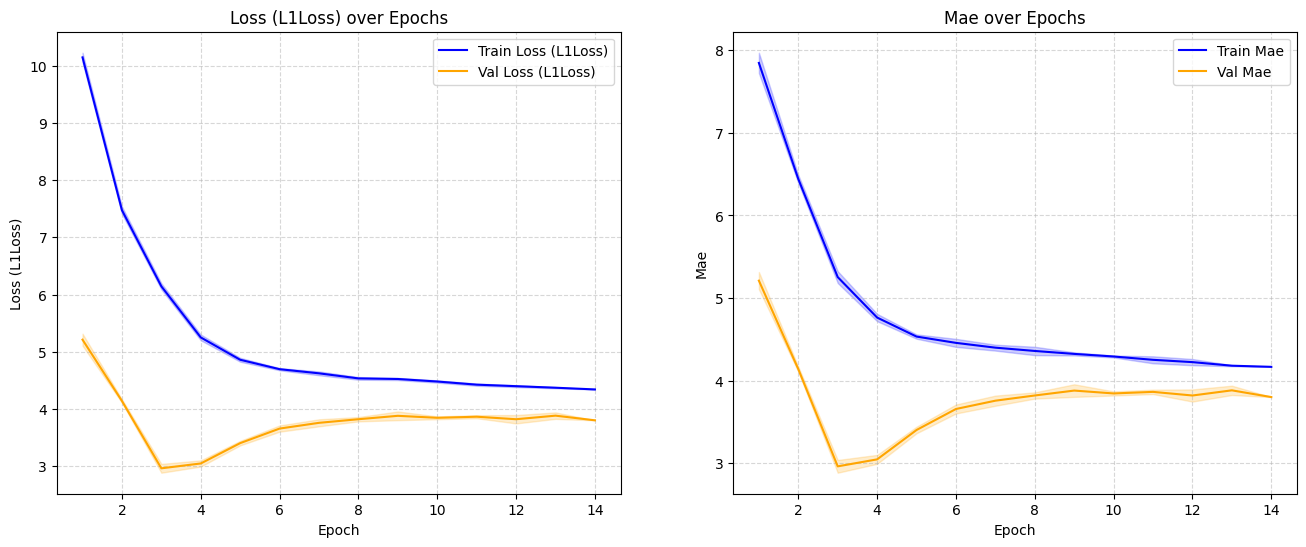

In [15]:
sage_model = SAGEModel(
    data=data,
    col_stats_dict=col_stats_dict,
    in_channels=in_channels,
    gnn_config=config["gnn_heads"]["sage"],
    mlp_config=mlp_config,
    task_type=task_type,
    dropout=dropout
).to(device)

criterion = torch.nn.L1Loss()
optimizer = torch.optim.AdamW(sage_model.parameters(), lr=learning_rate)

trainer = Trainer(
    task=task,
    model=sage_model,
    optimizer=optimizer,
    criterion=criterion,
    device=device
)

trainer.run_experiment(
    loader_dict,
    num_epochs,
    tune_metric="mae",
    higher_is_better=False,
    patience=10,
    print_every=3,
    num_runs=num_runs
)

# torch.save(best_weights, os.path.join(cache_dir, dataset_name, f"{sage_model.gnn_name}_{task_name}_best_weights.pt"))

del sage_model, optimizer, trainer
torch.cuda.empty_cache()
gc.collect()

## HGT


MODEL INFO:
Model name: HGT
Number of parameters: 6460600


STARTING RUN 1/5


Evaluating: 100%|██████████| 2/2 [00:00<00:00, 10.74it/s]


Epoch 1/30 | Train Loss: 11.0922 | Train mae: 8.0723
Epoch 1/30 |   Val Loss: 5.3926 |   Val mae: 5.3926
New best model found with Val mae: 5.3926


Evaluating: 100%|██████████| 2/2 [00:00<00:00, 12.22it/s]


New best model found with Val mae: 4.1712


...

Evaluating: 100%|██████████| 2/2 [00:00<00:00, 11.71it/s]


!!! No improvement in Val mae for 10 epochs (Early stopping at epoch 13) !!!


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 15.28it/s]


Run 5/5 | Final Train Metrics: {'mae': 5.787433624267578, 'mse': 55.85103225708008, 'r2': -0.13163435459136963, 'loss': 5.787433988053447}
Run 5/5 | Final Val Metrics: {'mae': 3.8332126140594482, 'mse': 21.182552337646484, 'r2': 0.014452159404754639, 'loss': 3.8332126871617382}
Run 5/5 | Final Test Metrics: {'mae': 4.251557350158691, 'mse': 25.73493194580078, 'r2': 0.052054643630981445, 'loss': 4.251557094172427}
FINISHED RUN 5/5


FINAL STATS OVER 5 RUNS

[TRAIN] Metrics:
  Mae: 5.4683 ± 0.3659
  Mse: 49.3951 ± 7.3228
  R2: -0.0008 ± 0.1484
  Loss: 5.4683 ± 0.3659

[VAL] Metrics:
  Mae: 3.8292 ± 0.0154
  Mse: 22.0839 ± 0.9064
  R2: -0.0275 ± 0.0422
  Loss: 3.8292 ± 0.0154

[TEST] Metrics:
  Mae: 4.2645 ± 0.0597
  Mse: 26.3735 ± 1.0204
  R2: 0.0285 ± 0.0376
  Loss: 4.2645 ± 0.0597



12

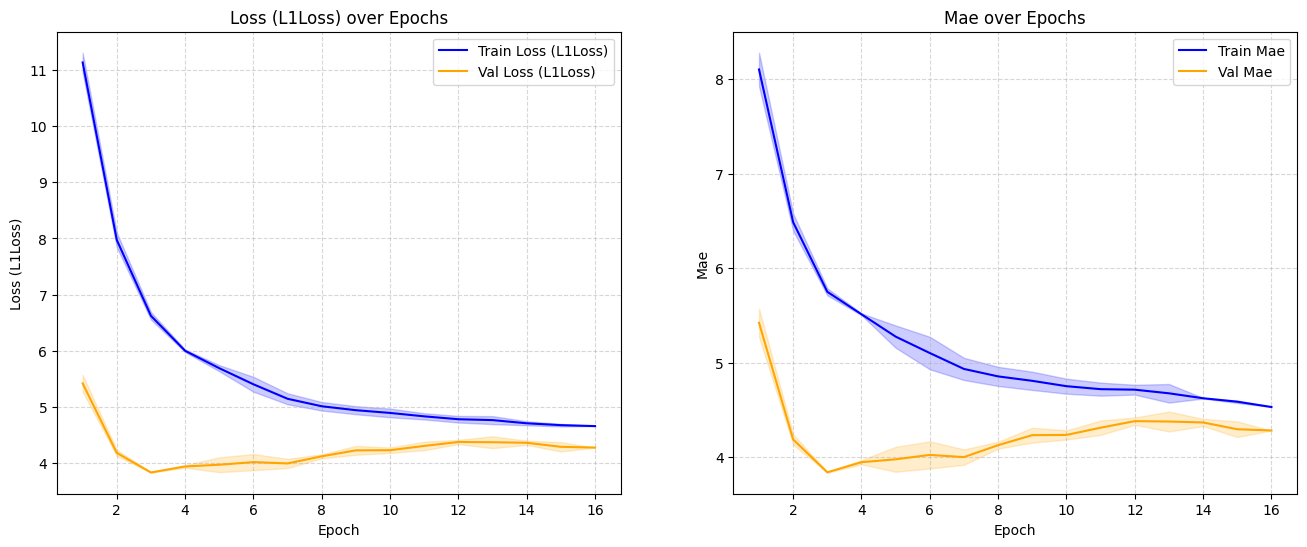

In [14]:
hgt_model = HGTModel(
    data=data,
    col_stats_dict=col_stats_dict,
    in_channels=in_channels,
    gnn_config=config["gnn_heads"]["hgt"],
    mlp_config=mlp_config,
    task_type=task_type,
    dropout=dropout
).to(device)

criterion = torch.nn.L1Loss()
optimizer = torch.optim.AdamW(hgt_model.parameters(), lr=learning_rate)

trainer = Trainer(
    task=task,
    model=hgt_model,
    optimizer=optimizer,
    criterion=criterion,
    device=device
)

trainer.run_experiment(
    loader_dict,
    num_epochs,
    tune_metric="mae",
    higher_is_better=False,
    patience=10,
    print_every=3,
    num_runs=num_runs
)

# torch.save(best_weights, os.path.join(cache_dir, dataset_name, f"{hgt_model.gnn_name}_{task_name}_best_weights.pt"))

del hgt_model, optimizer, trainer
torch.cuda.empty_cache()
gc.collect()